# Standard NN classifier overconfidence 
Dr Claire Villette

In [22]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import torchvision

In [49]:
transform = transforms.Compose([transforms.ToTensor()])

mnist_train = datasets.MNIST("./data", train=True, download=True, transform=transform)
mnist_loader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)

mnist_test  = datasets.MNIST(root="data", train=False, download=True, transform=transform)
mnist_test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=4, shuffle=True)

fashion_test = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)
fashion_loader = torch.utils.data.DataLoader(fashion_test, batch_size=4, shuffle=False)

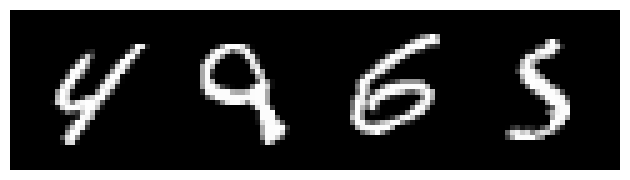

In [51]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

images, labels = next(iter(mnist_test_loader))
imshow(torchvision.utils.make_grid(images.cpu()))

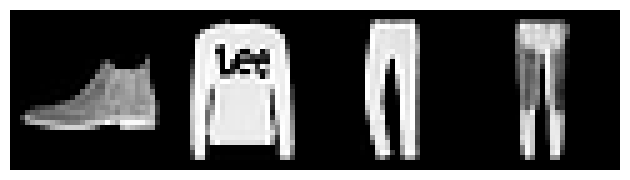

In [53]:
images, labels = next(iter(fashion_loader))
imshow(torchvision.utils.make_grid(images.cpu()))

In [60]:
mnist_test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=1, shuffle=True)
fashion_loader = torch.utils.data.DataLoader(fashion_test, batch_size=1, shuffle=True)

In [24]:
# Small model (same as in previous example)
class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(784, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        return self.fc2(F.relu(self.fc1(x)))

net = Net()

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
net = net.to(device)

opt = torch.optim.Adam(net.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

epochs = 10
batch_size = 16
for epoch in range(epochs):
    net.train()
    total_loss = 0
    total = 0

    for images, labels in mnist_loader:
        images, labels = images.to(device), labels.to(device)

        opt.zero_grad()
        loss = loss_fn(net(images), labels)
        loss.backward()
        opt.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    avg_loss = total_loss / total
    print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f}")


Epoch 1/10 - loss: 0.1566
Epoch 2/10 - loss: 0.1058
Epoch 3/10 - loss: 0.0784
Epoch 4/10 - loss: 0.0614
Epoch 5/10 - loss: 0.0494
Epoch 6/10 - loss: 0.0395
Epoch 7/10 - loss: 0.0321
Epoch 8/10 - loss: 0.0267
Epoch 9/10 - loss: 0.0223
Epoch 10/10 - loss: 0.0181


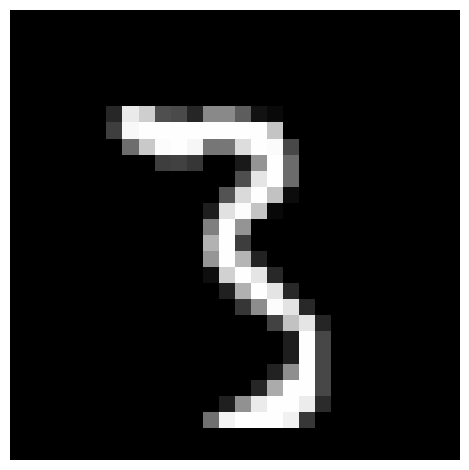

Predicted digit: 3
Confidence: 0.9998844861984253
Ground truth; It's MNIST class 3


In [59]:
# Test on MNIST
net.eval()
images, labels = next(iter(mnist_test_loader))
logits = net(images)
probs = torch.softmax(logits, dim=1)

imshow(torchvision.utils.make_grid(images.cpu()))

print("Predicted digit:", probs.argmax().item())
print("Confidence:", probs.max().item())
print("Ground truth; It's MNIST class", labels.item())

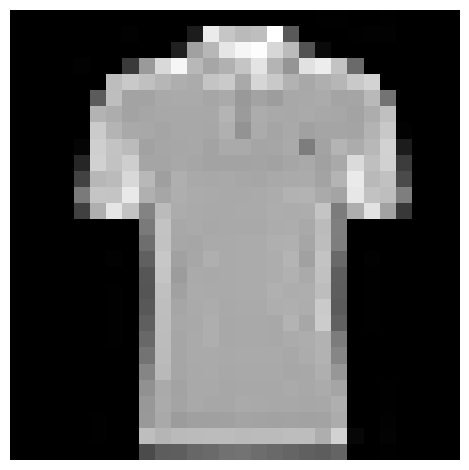

Predicted digit: 3
Confidence: 0.9545445442199707
Ground truth; it's not a digit at all! It's Fashion-MNIST class 0


In [77]:
# Test on Fashion‑MNIST
net.eval()
images, labels = next(iter(fashion_loader))
logits = net(images)
probs = torch.softmax(logits, dim=1)

imshow(torchvision.utils.make_grid(images.cpu()))

print("Predicted digit:", probs.argmax().item())
print("Confidence:", probs.max().item())
print("Ground truth; it's not a digit at all! It's Fashion-MNIST class", labels.item())